# CE workload-order Q-error timeline

This notebook shows how Q-error changes as workloads switch.

- Workload order is fixed by `WORKLOADS` (no timestamp ordering across workloads).
- Within each workload, queries are sorted by timestamp if available; otherwise shuffled.
- Each workload is split into `GROUPS_PER_WORKLOAD` chunks; each chunk is summarized by median Q-error.


In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Config
def _find_repo_root(start: Path) -> Path:
    for parent in (start, *start.parents):
        if (parent / "tasks").exists():
            return parent
    return start

BASE_DIR = _find_repo_root(Path.cwd())
RESULT_DIRS = [
    BASE_DIR / "tasks/cardinality_estimation/ce_timeline_census/result/census13",
    BASE_DIR / "existing_benchmarks/AreCELearnedYet/output/result/census13",
]
BASE_VERSION = "original"
ESTIMATORS = ["postgres", "naru", "mscn"]
WORKLOADS = [
    "census_trend_phase_1",
    "census_trend_phase_2",
    "census_trend_phase_3",
    "census_trend_phase_4",
    "census_trend_phase_5",
    "census_trend_phase_6",
]
WORKLOAD_SHORT_LABELS = [f"w{i+1}" for i in range(len(WORKLOADS))]
TIME_LABELS = [f"t{i}" for i in range(len(WORKLOADS))]
SHOW_TIME_AXIS = True
GROUPS_PER_WORKLOAD = 10
FALLBACK_VALUE = 0.0
SHUFFLE_SEED = 42
USE_LOG_SCALE = True
BOX_WIDTH = 1.0
SAVE_FIGS = True
OUTPUT_DIR = BASE_DIR / "tasks/cardinality_estimation/ce_timeline_census/figures"
OVERLEAF_DIR = "/Users/guanlil1/Dropbox/应用/Overleaf/DataWorkloadGen/figures"

def _save_fig(fig, file_name):
    if not SAVE_FIGS or not file_name:
        return
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / f"{file_name}.png", format="png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{file_name}.pdf", format="pdf", bbox_inches="tight")
    if OVERLEAF_DIR:
        overleaf = Path(OVERLEAF_DIR).expanduser()
        overleaf.mkdir(parents=True, exist_ok=True)
        fig.savefig(overleaf / f"{file_name}.pdf", format="pdf", bbox_inches="tight")
MIN_PLOT_QERROR = 1e-6
PRINT_USED_FILES = True


In [3]:
def _find_result_path(workload, estimator):
    name = f"{BASE_VERSION}-{workload}-{estimator}.csv"
    for root in RESULT_DIRS:
        path = root / name
        if path.exists():
            return path
    return None


def _read_results(path):
    try:
        df = pd.read_csv(path)
    except Exception:
        return None
    if df is None or df.empty:
        return None
    return df


def _sorted_qerrors(df, seed):
    if df is None:
        return []
    if "error" in df.columns:
        q = df["error"]
    elif "qerror" in df.columns:
        q = df["qerror"]
    else:
        return []

    if "ts" in df.columns:
        ts = pd.to_datetime(df["ts"], errors="coerce")
        if ts.notna().any():
            df = df.assign(_ts=ts).sort_values("_ts", kind="mergesort")
        else:
            df = df.sample(frac=1.0, random_state=seed)
    else:
        df = df.sample(frac=1.0, random_state=seed)
    return df.loc[df.index, q.name].to_list()


def _split_groups(values, groups, fallback):
    if not values:
        return [fallback] * groups
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return [fallback] * groups
    chunks = np.array_split(arr, groups)
    medians = []
    for chunk in chunks:
        chunk = chunk[~np.isnan(chunk)]
        medians.append(float(np.median(chunk)) if chunk.size else fallback)
    return medians

def _split_group_values(values, groups, fallback):
    if not values:
        return [[fallback] for _ in range(groups)]
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return [[fallback] for _ in range(groups)]
    chunks = np.array_split(arr, groups)
    grouped = []
    for chunk in chunks:
        chunk = chunk[~np.isnan(chunk)]
        if chunk.size == 0:
            grouped.append([fallback])
        else:
            grouped.append(chunk.tolist())
    return grouped


In [4]:
raw_errors = {}
records = []
missing = []
for w_idx, workload in enumerate(WORKLOADS):
    for e_idx, estimator in enumerate(ESTIMATORS):
        path = _find_result_path(workload, estimator)
        if PRINT_USED_FILES:
            print(f"{workload} {estimator}: {path}")
        seed = SHUFFLE_SEED + (w_idx * 100) + e_idx
        if path is None:
            errors = []
            raw_errors[(workload, estimator)] = errors
            missing.append((workload, estimator))
        else:
            df = _read_results(path)
            errors = _sorted_qerrors(df, seed)
            raw_errors[(workload, estimator)] = errors
            if df is None:
                missing.append((workload, estimator))
        group_medians = _split_groups(errors, GROUPS_PER_WORKLOAD, FALLBACK_VALUE)
        for g_idx, median in enumerate(group_medians):
            segment = (w_idx * GROUPS_PER_WORKLOAD) + g_idx
            records.append({
                "workload": workload,
                "estimator": estimator,
                "group": g_idx,
                "segment": segment,
                "qerror": median,
            })

seg_df = pd.DataFrame(records)
seg_df["plot_qerror"] = seg_df["qerror"]
if USE_LOG_SCALE:
    seg_df["plot_qerror"] = seg_df["plot_qerror"].clip(lower=MIN_PLOT_QERROR)
if missing:
    print("Missing or empty result files (fallback=0):")
    for workload, estimator in sorted(set(missing)):
        print(f"  {workload} {estimator}")

seg_df.head()


census_trend_phase_1 postgres: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/cardinality_estimation/ce_timeline_census/result/census13/original-census_trend_phase_1-postgres.csv
census_trend_phase_1 naru: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/cardinality_estimation/ce_timeline_census/result/census13/original-census_trend_phase_1-naru.csv
census_trend_phase_1 mscn: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/cardinality_estimation/ce_timeline_census/result/census13/original-census_trend_phase_1-mscn.csv
census_trend_phase_2 postgres: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/cardinality_estimation/ce_timeline_census/result/census13/original-census_trend_phase_2-postgres.csv
census_trend_phase_2 naru: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/cardinality_estimation/ce_timeline_census/result/census13/original-census_trend_phase_2-naru.csv
census_trend_p

,workload,estimator,group,segment,qerror,plot_qerror
0,census_trend_phase_1,postgres,0,0,2.730046,2.730046
1,census_trend_phase_1,postgres,1,1,2.728668,2.728668
2,census_trend_phase_1,postgres,2,2,2.730471,2.730471
3,census_trend_phase_1,postgres,3,3,2.758147,2.758147
4,census_trend_phase_1,postgres,4,4,2.698973,2.698973


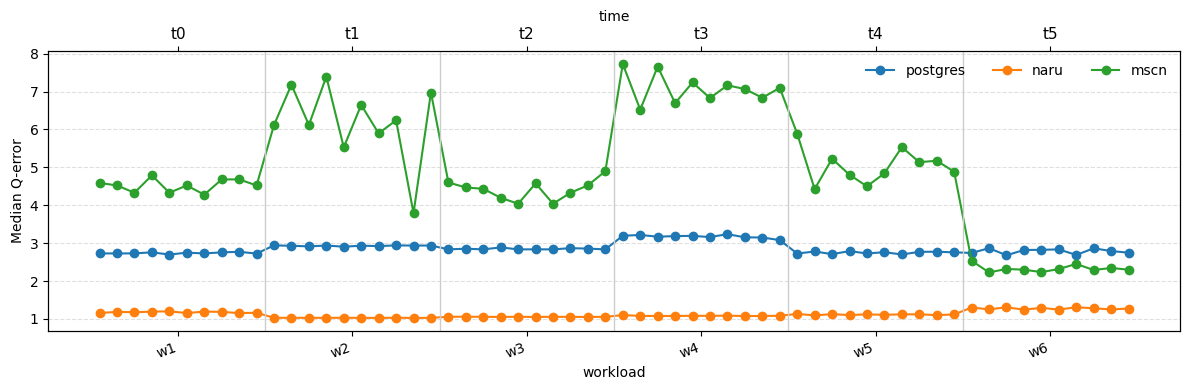

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))

for estimator in ESTIMATORS:
    sub = seg_df[seg_df["estimator"] == estimator]
    ax.plot(sub["segment"], sub["plot_qerror"], marker="o", linewidth=1.5, label=estimator)

# Workload separators
for i in range(1, len(WORKLOADS)):
    ax.axvline((i * GROUPS_PER_WORKLOAD) - 0.5, color="0.8", linewidth=1)

centers = [i * GROUPS_PER_WORKLOAD + (GROUPS_PER_WORKLOAD - 1) / 2 for i in range(len(WORKLOADS))]
ax.set_xticks(centers)
ax.set_xticklabels(WORKLOAD_SHORT_LABELS, rotation=20, ha="right")
if SHOW_TIME_AXIS and TIME_LABELS:
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(centers)
    ax_top.set_xticklabels(TIME_LABELS, fontsize=11)
    ax_top.set_xlabel("time")

ax.set_xlabel("workload")
ax.set_ylabel("Median Q-error")
# if USE_LOG_SCALE:
#     ax.set_yscale("log")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend(ncol=len(ESTIMATORS), frameon=False)
plt.tight_layout()
file_name = "workload_order_qerror_line"
_save_fig(fig, file_name)
plt.show()


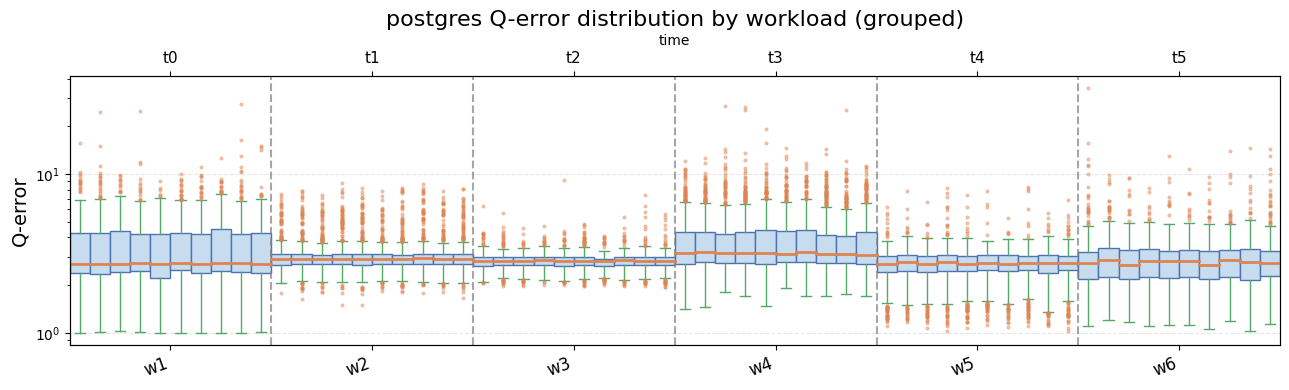

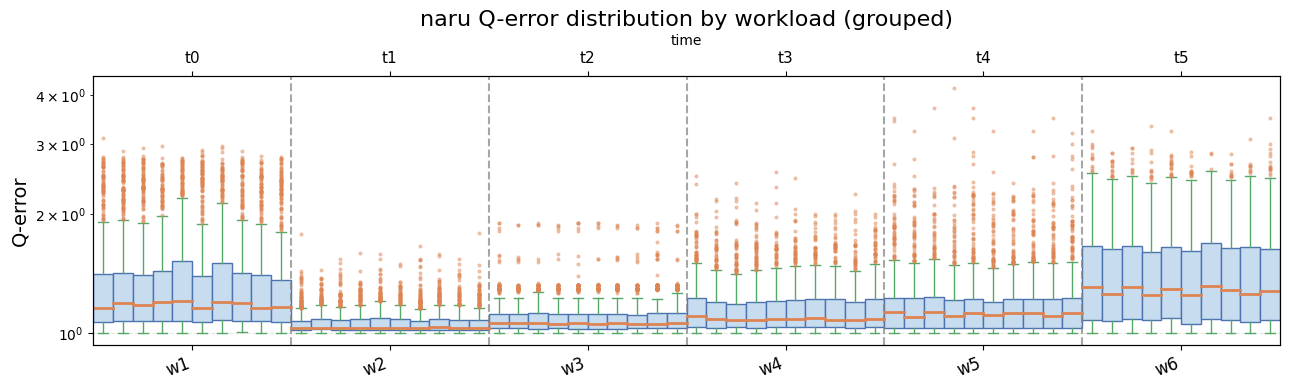

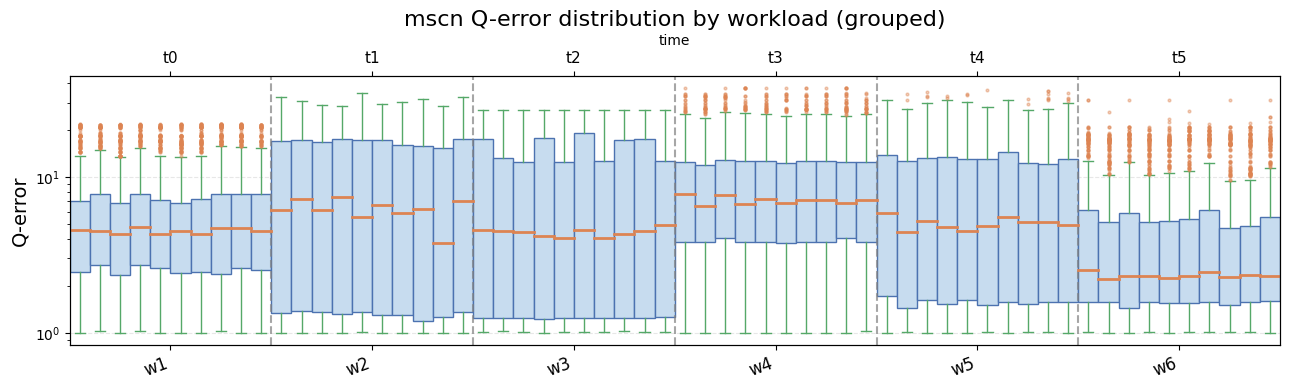

In [6]:
def plot_qerror_boxplot(values_by_group, group_titles, group_size, title, use_log):
    fig, ax = plt.subplots(figsize=(13, 4))

    # Clip for log scale to avoid zeros
    plot_values = []
    for vals in values_by_group:
        arr = np.asarray(vals, dtype=float)
        if use_log:
            arr = np.clip(arr, MIN_PLOT_QERROR, None)
        plot_values.append(arr)

    positions = list(range(1, len(plot_values) + 1))
    ax.boxplot(
        plot_values,
        positions=positions,
        widths=BOX_WIDTH,
        patch_artist=True,
        boxprops=dict(facecolor="#c7dcef", color="#4c72b0"),
        medianprops=dict(color="#dd8452", linewidth=2),
        whiskerprops=dict(color="#55a868"),
        capprops=dict(color="#55a868"),
        flierprops=dict(marker="o", markersize=2, alpha=0.4,
                        markerfacecolor="#dd8452", markeredgecolor="#dd8452"),
    )
    ax.set_xlim(0.5, len(plot_values) + 0.5)

    if group_size:
        for i in range(group_size, len(values_by_group), group_size):
            ax.axvline(x=i + 0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)

    if group_titles:
        centers = [i * group_size + (group_size + 1) / 2 for i in range(len(group_titles))]
        ax.set_xticks(centers)
        ax.set_xticklabels(WORKLOAD_SHORT_LABELS, rotation=20, ha="right", fontsize=12)
        if SHOW_TIME_AXIS and TIME_LABELS:
            ax_top = ax.twiny()
            ax_top.set_xlim(ax.get_xlim())
            ax_top.set_xticks(centers)
            ax_top.set_xticklabels(TIME_LABELS, fontsize=11)
            ax_top.set_xlabel("time")
    else:
        ax.set_xticks([])

    ax.set_ylabel("Q-error", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)
    if use_log:
        ax.set_yscale("log")
    fig.tight_layout()
    _save_fig(fig, title.replace(" ", "_").lower())
    plt.show()

for estimator in ESTIMATORS:
    values = []
    for workload in WORKLOADS:
        errors = raw_errors.get((workload, estimator), [])
        values.extend(_split_group_values(errors, GROUPS_PER_WORKLOAD, FALLBACK_VALUE))
    plot_qerror_boxplot(
        values,
        WORKLOAD_SHORT_LABELS,
        GROUPS_PER_WORKLOAD,
        f"{estimator} Q-error distribution by workload (grouped)",
        USE_LOG_SCALE,
    )
